# Lab 3 - Stat 153/248

This lab will go into concepts from Lectures 5 and 6 (covering linear regression). This includes:

1. Fitting ordinary least squares (OLS) regression
2. Simulating many regressions, determining bias in coefficients
3. More examples of OLS
   
For this lab, you will fill in the aspects of the code marked `...` or with the comment `# FILL IN`

In [2]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import statsmodels.api as sm # This contains the model fitting libraries for linear regression 
from statsmodels.graphics.tsaplots import plot_acf # autocorrelation function

#!pip install astsa
import astsa # You should have pip installed this for Lab 1.. if not, uncomment line above

# Set the random seed, this is so you will generate the same answers
# each time (for example, when generating white noise)
np.random.seed(42) 

First we'll start with a simple example where we have a linear trend plus noise. We'll take a sample from this function and try to fit a regression line to predict $y$ from $t$. 

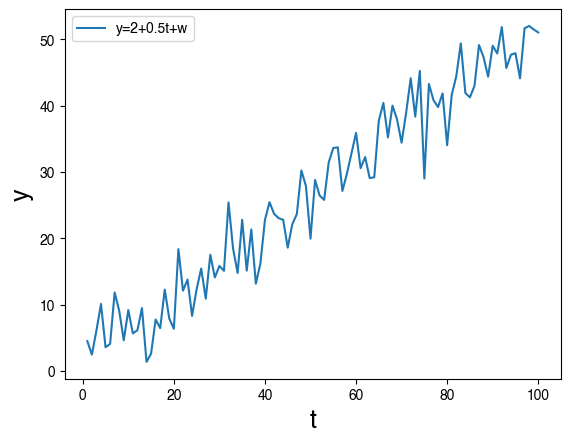

In [3]:
t = np.arange(1, 101)
sigma = #FILL IN # If sigma=1, standard normal
beta0 = #FILL IN
beta1 = #FILL IN
y = beta0 + beta1*t + sigma*np.random.randn(len(t))

plt.plot(t,y,label='y=2+0.5t+w')
plt.xlabel('t',fontsize=18)
plt.ylabel('y',fontsize=18)
plt.legend()

We will fit the simple model

$$y_i = \beta_0 + \beta_1 t + \epsilon_i$$

using Ordinary Least Squares (OLS) in the `statsmodels` library.

We first have to add a constant term to our model to be sure that we actually get an estimate of $\beta_0$

In [4]:
T = sm.add_constant(t)
linreg_simple2 = sm.OLS(y, T).fit()
print(linreg_simple2.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.942
Model:                            OLS   Adj. R-squared:                  0.942
Method:                 Least Squares   F-statistic:                     1601.
Date:                Thu, 05 Feb 2026   Prob (F-statistic):           1.62e-62
Time:                        11:01:59   Log-Likelihood:                -270.29
No. Observations:                 100   AIC:                             544.6
Df Residuals:                      98   BIC:                             549.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.3032      0.735      1.773      0.0

We can also report the confidence intervals on our estimates of $\beta_0$ and $\beta_1$, which can be useful for determining our certainty of these estimates.

In [5]:
ci_linreg_simple2 = linreg_simple2.conf_int(alpha=0.05)
print(ci_linreg_simple2)
print(f'95% confidence interval for B0$: [{ci_linreg_simple2[0,0]:.3f}, {ci_linreg_simple2[0,1]:.3f}]')
print(f'95% confidence interval for B1$: [{ci_linreg_simple2[1,0]:.3f}, {ci_linreg_simple2[1,1]:.3f}]')

[[-0.15543644  2.76178753]
 [ 0.48049713  0.53064895]]
95% confidence interval for B0$: [-0.155, 2.762]
95% confidence interval for B1$: [0.480, 0.531]


[[ 0.37185304  3.24564413]
 [ 0.89903144  3.7296118 ]
 [ 1.42609361  4.21369571]
 [ 1.95303407  4.69790132]
 [ 2.47984706  5.18223441]
 [ 3.00652647  5.66670107]
 [ 3.53306583  6.15130778]
 [ 4.05945832  6.63606137]
 [ 4.58569669  7.12096908]
 [ 5.11177328  7.60603856]
 [ 5.63767998  8.09127793]
 [ 6.16340821  8.57669578]
 [ 6.68894886  9.0623012 ]
 [ 7.21429231  9.54810382]
 [ 7.73942837 10.03411384]
 [ 8.26434624 10.52034205]
 [ 8.78903451 11.00679986]
 [ 9.31348109 11.49349935]
 [ 9.83767321 11.9804533 ]
 [10.36159738 12.46767521]
 [10.88523934 12.95517932]
 [11.40858405 13.44298068]
 [11.93161567 13.93109514]
 [12.45431749 14.41953939]
 [12.97667199 14.90833097]
 [13.49866072 15.39748831]
 [14.02026441 15.8870307 ]
 [14.54146287 16.37697831]
 [15.06223505 16.8673522 ]
 [15.58255907 17.35817426]
 [16.10241221 17.8494672 ]
 [16.62177101 18.34125447]
 [17.14061133 18.83356023]
 [17.6589084  19.32640923]
 [18.17663699 19.81982671]
 [18.69377151 20.31383827]
 [19.21028617 20.80846969]
 

Text(0, 0.5, 'y')

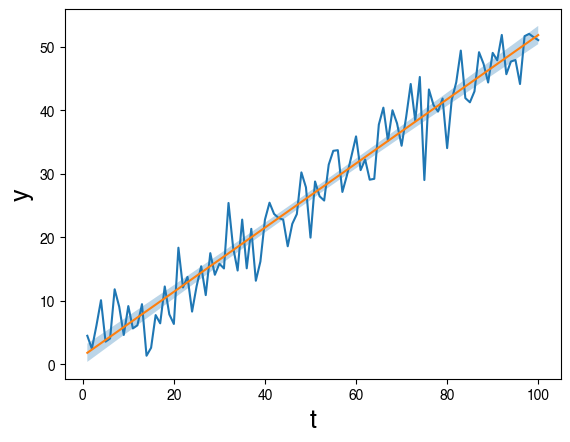

In [19]:
# Now plot the predictions - we can do this a few ways, either using
# `fitted values` or using the parameters directly:

yhat = linreg_simple2.fittedvalues

# We could also get the coefficients and use these to get yhat instead: 
betas = linreg_simple2.params 

plt.plot(t,y)
plt.plot(t,yhat)

# Try also creating yhat from the betas...
plt.plot(t,#FILL IN) 


# Show the predictions and confidence intervals

If we want to show the predicted data and confidence intervals for the fitted values, we can use `get_prediction`. We will then produce `pred_summary`, which contains:
* `mean` - fitted values
* `mean_ci_lower`, `mean_ci_upper` - confidence intervals for the mean
* `obs_ci_lower`, `obs_ci_upper` - prediction interval for new observations

Text(0, 0.5, 'y')

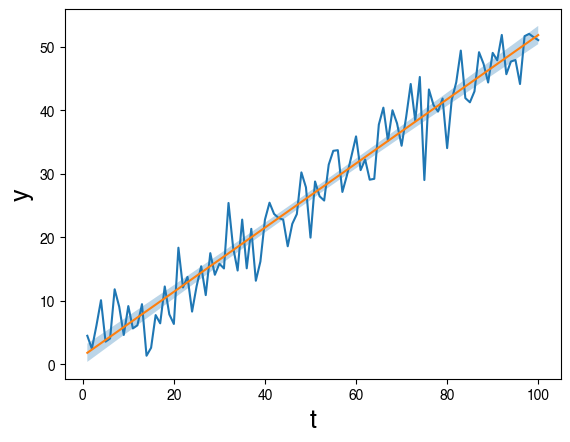

In [23]:
# To show the confidence intervals on the data, we can use the `get_prediction` method
# 
pred = linreg_simple2.get_prediction(T)
pred_ci = pred.conf_int(alpha=0.05)
pred_summary = pred.summary_frame(alpha=0.05)

plt.plot(t,y)
plt.plot(t, pred_summary['mean'])
plt.fill_between(t, pred_summary['mean_ci_lower'], pred_summary['mean_ci_upper'], alpha=0.3, label="95% CI (mean)")
#plt.fill_between(t, pred_summary['obs_ci_lower'], pred_summary['obs_ci_upper'], alpha=0.3, label="95% CI (mean)")

plt.xlabel('t',fontsize=18)
plt.ylabel('y',fontsize=18)

For time series, one thing we want to check is that our residuals (the difference between the predicted data and our actual value) are weakly stationary, which allows us to assume that our error $\epsilon_t$ is weakly stationary. 

We can do that by plotting the residuals over time as well as the autocorrelation function of the residuals. How does this look? 

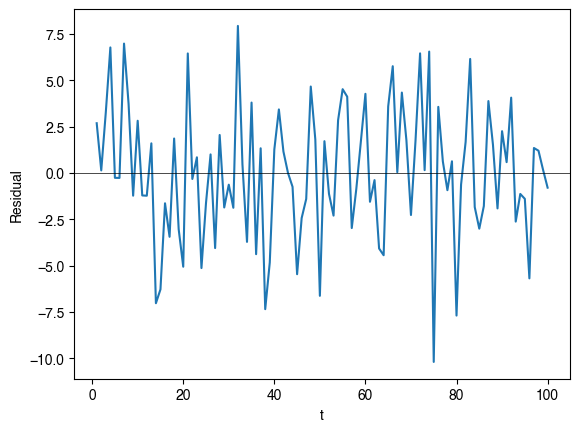

<Figure size 1000x500 with 0 Axes>

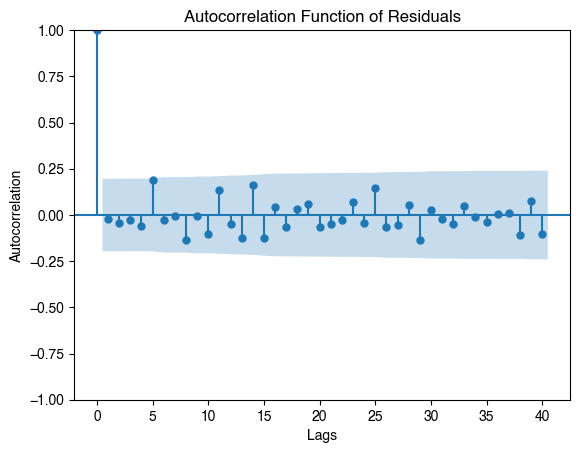

In [24]:
residuals = linreg_simple2.resid

plt.figure()
plt.plot(t,residuals)
plt.axhline(0, color='k', linewidth=0.5) # Horizontal line at 0
plt.xlabel('t')
plt.ylabel('Residual')

plt.figure(figsize=(10, 5))
plot_acf(residuals, lags=40, title='Autocorrelation Function of Residuals')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.show()

## The chicken example

Now let's load some data from `astsa`, for example, the price of chicken over time, from 2001 to 2016. As pointed out in your book, commodities (such as raw materials, basic resources, agricultural, or mining products) show specific fluctuations in their prices over time. For this example, we'll fit a regression model for chicken prices as our response $y$ and time as our predictor $x$.

In [27]:
chicken_data = astsa.load_chicken()
# Fix the time index
chicken_data['Time'] = pd.to_datetime(chicken_data['Time'])
chicken_data.set_index('Time', inplace=True)
print(chicken_data)

             Value
Time              
2001-08-01   65.58
2001-09-01   66.48
2001-10-01   65.70
2001-11-01   64.33
2001-12-01   63.23
...            ...
2016-03-01  111.56
2016-04-01  111.55
2016-05-01  111.98
2016-06-01  111.84
2016-07-01  111.46

[180 rows x 1 columns]


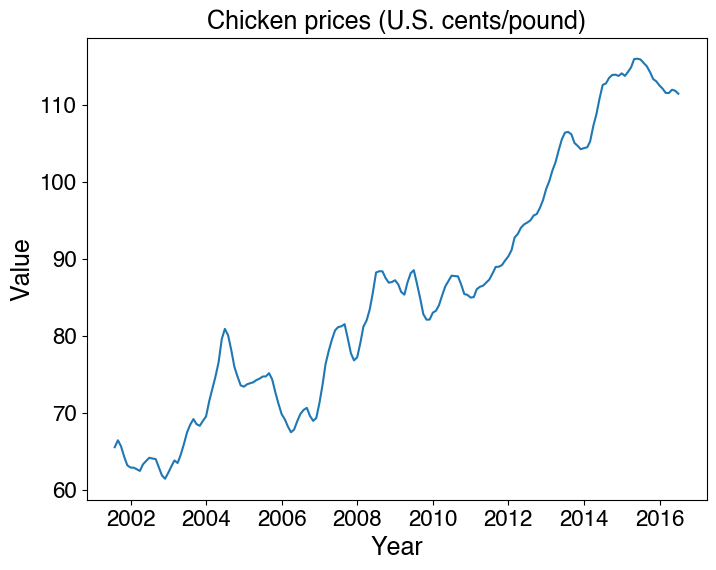

In [28]:
plt.figure(figsize=(8,6))
plt.plot(chicken_data.index, chicken_data['Value'], label='Value')
plt.xlabel('Year', fontsize=18)
plt.ylabel('Value', fontsize=18)
plt.title('Chicken prices (U.S. cents/pound)', fontsize=18)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16);

## Chicken price regression

We will fit a linear regression model to the chicken price data using time as the covariate. Here, the model is:

$$y_i = \beta_0 + \beta_1 x_i + \epsilon_i$$

where $y_i$ is the price of chicken at time index $i$, and $x_i = i$. We can interpret the coefficient $\beta_1$ as the numerical change in price of chicken from one month to the next (since each time step is in one month). From just looking at the graph, we know that the linear fit is likely not the best model for these data, since there are also underlying (potentially seasonal) fluctuations in the data. Still, we may be interested in the overall trend in price increases for this commodity.

We can then use statsmodels to fit the OLS solution for the line of best fit to the data. 

In [30]:
yvec = np.array(chicken_data['Value'])
n = len(yvec) # number of time points
xvec = np.arange(1, n+1)
X = sm.add_constant(xvec)
linreg2 = sm.OLS(yvec, X).fit()
print(linreg2.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.917
Model:                            OLS   Adj. R-squared:                  0.917
Method:                 Least Squares   F-statistic:                     1974.
Date:                Thu, 05 Feb 2026   Prob (F-statistic):           2.83e-98
Time:                        11:23:23   Log-Likelihood:                -532.83
No. Observations:                 180   AIC:                             1070.
Df Residuals:                     178   BIC:                             1076.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         58.5832      0.703     83.331      0.0

In [31]:
linreg2 = sm.OLS(yvec, X).fit()
print(linreg2.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.917
Model:                            OLS   Adj. R-squared:                  0.917
Method:                 Least Squares   F-statistic:                     1974.
Date:                Thu, 05 Feb 2026   Prob (F-statistic):           2.83e-98
Time:                        11:23:23   Log-Likelihood:                -532.83
No. Observations:                 180   AIC:                             1070.
Df Residuals:                     178   BIC:                             1076.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         58.5832      0.703     83.331      0.0

Now we have an estimate of $\beta_0$ (`const`) and an estimate of $\beta_1$ (`x1`). What this means is that the price of chicken is going up by approximately 0.30 cents per pound per month, and had started at a base price of 58.5 cents per pound.

We can also calculate the confidence intervals to understand the uncertainty associated with the estimate.

In [17]:
ci_linreg2 = linreg2.conf_int(alpha=0.05)
print(ci_linreg2)
print(f'95% confidence interval for price fluctuation: [{ci_linreg2[1,0]:.2f}, {ci_linreg2[1,1]:.2f}]')

[[57.19590866 59.97056185]
 [ 0.28604822  0.31263657]]
95% confidence interval for price fluctuation: [0.29, 0.31]


Now let's plot the regression line on the original data.

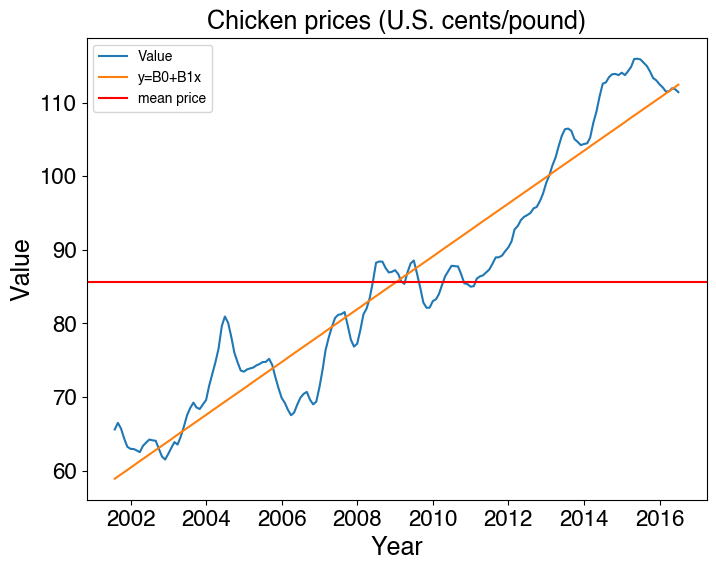

In [33]:
plt.figure(figsize=(8,6))
plt.plot(chicken_data.index, chicken_data['Value'], label='Value')
plt.plot(chicken_data.index, linreg2.fittedvalues, label='y=B0+B1x')
plt.axhline(chicken_data['Value'].mean(), color='r', label='mean price')
plt.xlabel('Year', fontsize=18)
plt.ylabel('Value', fontsize=18)
plt.title('Chicken prices (U.S. cents/pound)', fontsize=18)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16);
plt.legend()

What are some problems with this? Do our residuals show any strong or unmodeled dependence on time?

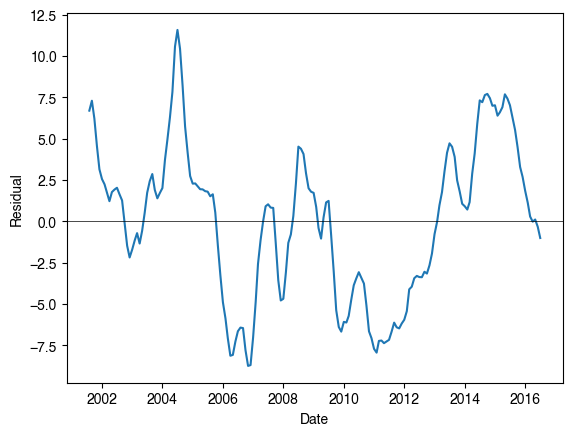

<Figure size 1000x500 with 0 Axes>

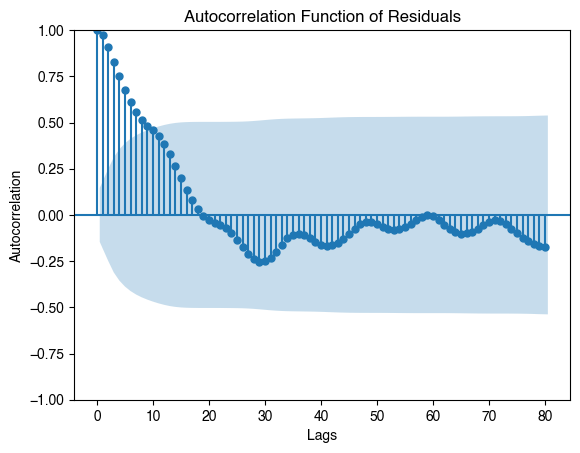

In [30]:
residuals = linreg2.resid

plt.figure()
plt.plot(chicken_data.index,residuals)
plt.axhline(0, color='k', linewidth=0.5) # Horizontal line at 0
plt.xlabel('Date')
plt.ylabel('Residual')

plt.figure(figsize=(10, 5))
plot_acf(residuals, lags=80, title='Autocorrelation Function of Residuals')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.show()

What if we took a moving average of the chicken data to smooth out some of the fluctuations? Here we will smooth over a 3 year + 1 month window (we are choosing an odd length window so it is centered around our observations). 

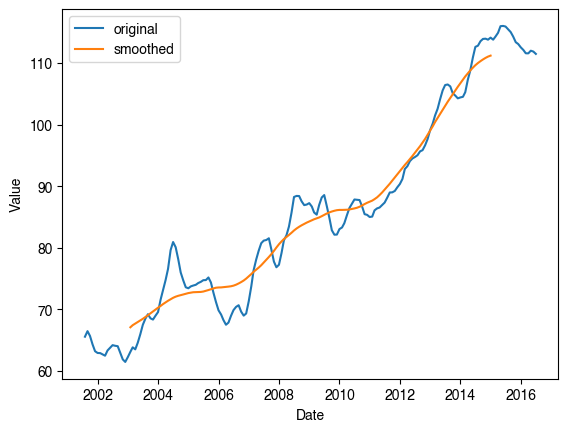

In [97]:
def moving_average(w, n):
    '''
    Create an acausal moving average of the time series `w` using an `n`-point moving average
    '''
    v = np.zeros((len(w),)) * np.nan
    half_win = n // 2
    for t in np.arange(half_win, len(w) - half_win):
        v[t] = np.mean(w[t-half_win : t+half_win+1])
    return v

smoothing_win = ## try a ~3 year window, but use an odd number.. think about how often data are sampled
chicken_smoothed = moving_average(chicken_data['Value'], n=smoothing_win)
plt.plot(chicken_data.index,chicken_data['Value'], label='original')
plt.plot(chicken_data.index,chicken_smoothed, label='smoothed')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()


In [98]:
# Now let's fit a regression to this:

yvec = np.array(chicken_smoothed)
n = len(yvec) # number of time points
xvec = np.arange(1, n+1)
X = sm.add_constant(xvec)
linreg_smooth = sm.OLS(yvec, X).fit()
print(linreg_smooth.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                         nan
Model:                            OLS   Adj. R-squared:                    nan
Method:                 Least Squares   F-statistic:                       nan
Date:                Thu, 05 Feb 2026   Prob (F-statistic):                nan
Time:                        12:20:04   Log-Likelihood:                    nan
No. Observations:                 180   AIC:                               nan
Df Residuals:                     178   BIC:                               nan
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const             nan        nan        nan        n

We got nans ("Not a Number"/undefined)! Why did this happen? It turns out when we defined our moving average, we only calculated the windowed average once we got enough samples, so the beginning and end of our function is now undefined. 

To make this work out, we have to remove the nan values as follows:

In [99]:
yvec = np.array(chicken_smoothed[~np.isnan(chicken_smoothed)]) # Take only the points that are *not* NaN (that's what ~ is shorthand for)
n = len(yvec) # number of time points
xvec = np.arange(1, n+1)
print(len(yvec), len(xvec))
X = sm.add_constant(xvec)
linreg_smooth = sm.OLS(yvec, X).fit()
print(linreg_smooth.summary())

144 144
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.949
Model:                            OLS   Adj. R-squared:                  0.949
Method:                 Least Squares   F-statistic:                     2635.
Date:                Thu, 05 Feb 2026   Prob (F-statistic):           1.41e-93
Time:                        12:20:05   Log-Likelihood:                -353.12
No. Observations:                 144   AIC:                             710.2
Df Residuals:                     142   BIC:                             716.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         63.8031      0.474    134.568 

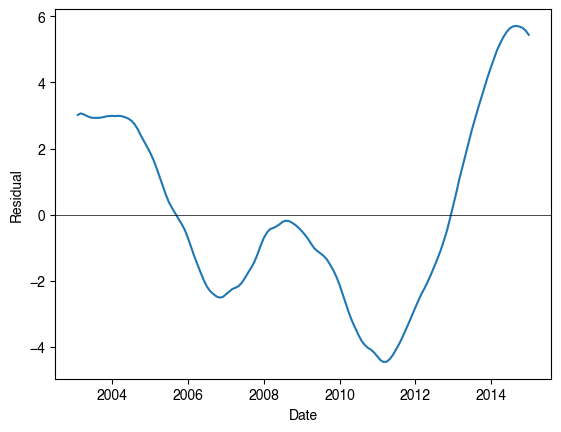

<Figure size 1000x500 with 0 Axes>

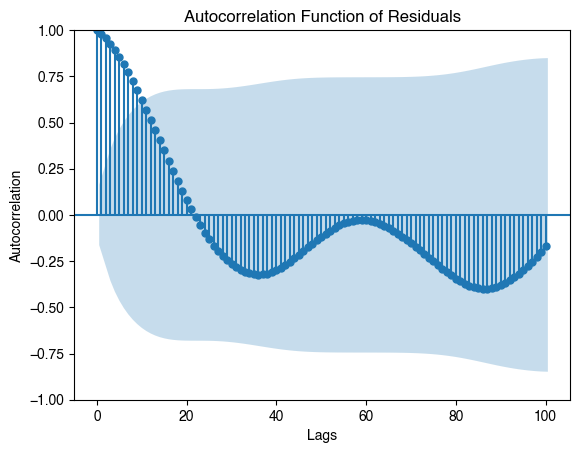

In [101]:
residuals_smooth = linreg_smooth.resid

# Make sure we get the new time index as well
half_win = smoothing_win // 2
new_t = [chicken_data.index[a] for a in np.arange(half_win, len(chicken_data.index) - half_win)]

plt.figure()
plt.plot(new_t,residuals_smooth)
plt.axhline(0, color='k', linewidth=0.5) # Horizontal line at 0
plt.xlabel('Date')
plt.ylabel('Residual')

plt.figure(figsize=(10, 5))
plot_acf(residuals_smooth, lags=100, title='Autocorrelation Function of Residuals')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.show();

As it turns out, there are still pretty strong autocorrelations in these data, even when we apply the moving average, so probably we will want to do some differencing or other transformations first.

# Lecture 6 review

Now as in Lecture 6, we are going to start with a known function $y = \beta_0 + \beta_1 x + w_t$. We will assume that $w_t$ is noise taken from a Gaussian distribution $\sim N(0, \sigma^2)$. Here we will choose arbitrary values for each of these. 

We will draw samples from this function and then compute our estimated $\beta_0$, $\beta_1$, and $\sigma^2$ through the MLE functions we derived in lecture. 

In [103]:
beta0 = # FILL IN
beta1 = # FILL IN
sigma2 = # FILL IN

# n is the number of time points
n = # Try high and low numbers for this
x = np.arange(1,n+1)

# how many times to repeat the simulation
nsamps = 1000 # try sampling either more or less than this, see how your estimates behave
y = beta0 + beta1*x + np.random.randn(nsamps,n)*np.sqrt(sigma2)

print('y is of shape', y.shape)

y is of shape (10000, 10)


Now we will use the MLE solutions for estimating each of these parameters from our sampled data.

In [104]:
# Initialize values for our estimates
beta0_hat = np.zeros(nsamps,)
beta1_hat = np.zeros(nsamps,)
sigma2_hat = np.zeros(nsamps,)
sigma2_hat_unbiased = np.zeros(nsamps,)

for i in np.arange(nsamps):
    beta1_hat[i] = np.sum((y[i,:]-y[i,:].mean())*(x-x.mean()))/np.sum((x-x.mean())**2)
    beta0_hat[i] = y[i,:].mean() - beta1_hat[i] * x.mean()
    sigma2_hat[i] = 1/n*np.sum((y[i,:] - beta0_hat[i] - beta1_hat[i]*x)**2)
    sigma2_hat_unbiased[i] = sigma2_hat[i]*n/(n-2)

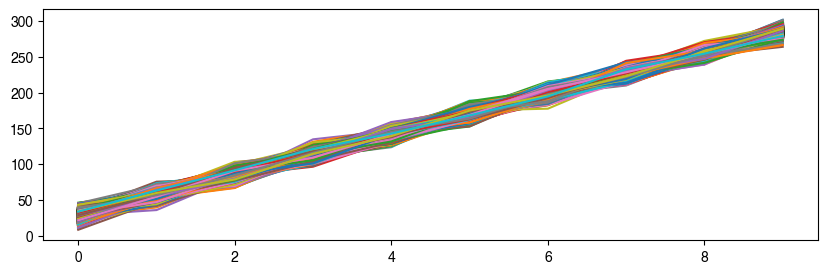

In [105]:
plt.figure(figsize=(10,3))
plt.plot(y.T);

Text(0.5, 1.0, 'sigma2 estimate')

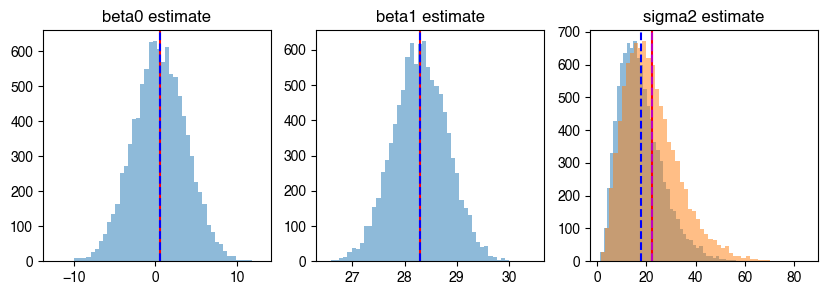

In [106]:
plt.figure(figsize=(10,3))
plt.subplot(1,3,1)
plt.hist(beta0_hat, bins=50, alpha=0.5);
plt.axvline(beta0, color='r')
plt.axvline(beta0_hat.mean(), color='blue', linestyle='--')
plt.title('beta0 estimate')

plt.subplot(1,3,2)
plt.hist(beta1_hat, bins=50, alpha=0.5);
plt.axvline(beta1, color='r')
plt.axvline(beta1_hat.mean(), color='blue', linestyle='--')
plt.title('beta1 estimate')

plt.subplot(1,3,3)
plt.hist(sigma2_hat, bins=50, alpha=0.5);
plt.axvline(sigma2_hat.mean(), color='blue', linestyle='--')
plt.hist(sigma2_hat_unbiased, bins=50, alpha=0.5);
plt.axvline(sigma2, color='r')
plt.axvline(sigma2_hat_unbiased.mean(), color='m', linestyle='--')
plt.title('sigma2 estimate')

In [107]:
print(np.mean(sigma2_hat), np.std(sigma2_hat))
print(np.mean(sigma2_hat_unbiased), np.std(sigma2_hat_unbiased))
print(sigma2)

17.726358503291888 8.794352684562693
22.157948129114857 10.992940855703367
22.2


In [ ]:
# If you finish early -- try loading another dataset like the DJIA dataset and running the same analysis. What do you notice?